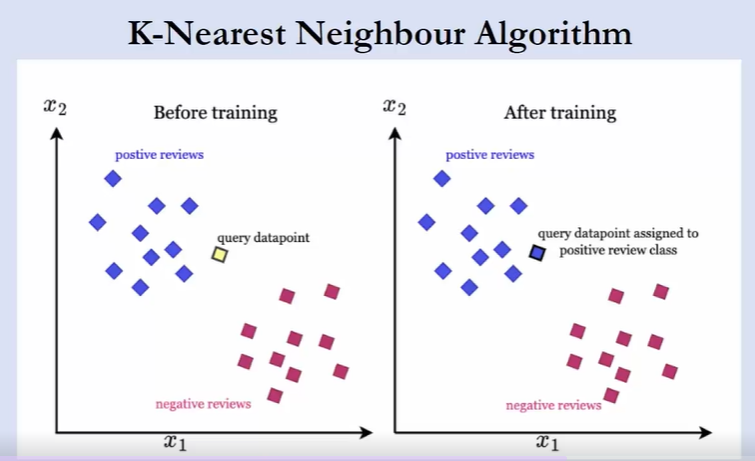

## What is KNN?

K-Nearest Neighbors (KNN) is a simple, instance-based supervised learning algorithm used for both classification and regression.

* It doesn't learn an internal model.
* Instead, it stores the entire training dataset, and makes predictions based on the 'k' closest points.

Key idea: "You are what your neighbors are."

---

## How Does KNN Work?

Given a new input `x_new`:

1. Compute the distance between `x_new` and all training points.
2. Sort all distances and find the $k$ nearest neighbors.
3. Vote:

* For classification: majority class among the neighbors.
* For regression: average of neighbors' values.

4. Return the predicted class/value.

🚀 KNN is lazy (no training phase) but powerful with well-chosen features and proper scaling.

---

## Mathematics Behind KNN

$$\text{distance}(x_i, x_j) = \sqrt{\sum_{d=1}^{n} (x_{id} - x_{jd})^2}$$

* This measures straight-line distance in multi-dimensional space.

* Other distance metrics: Manhattan, Minkowski, Cosine (optional extensions).

🔍 **Why Distance Metrics Matter in KNN?**

KNN relies on the "closeness" of data points to make predictions. The **distance metric** determines *how* we measure this closeness in feature space.

Depending on the nature of the data (e.g., continuous, categorical, outliers), different metrics might work better.

🔶 **Example: Predicting Loan Approval (Classification)**

Suppose we have two features:

* Age
* Income

* Age = 40, Income = 70k

We have two historical clients:

* **A**: Age = 38, Income = 90k, Approved ✅
* **B**: Age = 60, Income = 70k, Rejected ❌

Let's compute distances:

**Using Euclidean Distance:**

$$\text{Distance to A} = \sqrt{(40 - 38)^2 + (70 - 90)^2} = \sqrt{4 + 400} = \sqrt{404} \approx 20.1$$

$$\text{Distance to B} = \sqrt{(40 - 60)^2 + (70 - 70)^2} = \sqrt{400 + 0} = 20.0$$

🔶 KNN will pick **B** as the nearest neighbor $\rightarrow$ Predict **Rejected**

## Using Manhattan Distance:

$$\text{To A} = \vert{}40 - 38\vert{} + \vert{}70 - 90\vert{} = 2 + 20 = 22$$

$$\text{To B} = \vert{}40 - 60\vert{} + \vert{}70 - 70\vert{} = 20 + 0 = 20$$

$\rightarrow$ **Still B is closer** $\rightarrow$ **Predict Rejected**

But imagine if we **normalize features** (scale Income), then **Age may dominate**, and **A becomes closer** — leading to a **different classification**.

## In KNN Regression

The **prediction** is the **average** of neighbors' values, so different neighbors $\rightarrow$ different predicted outputs.

---

## How to decide about distance method

✅ 1. Start with Euclidean Distance (Default Choice)

> "For our first KNN model, we'll use the most common and intuitive distance measure: Euclidean distance --- the straight-line distance between two points. It works well when features are continuous and have been normalized."

This gives a solid starting point.

❗ 2. Caution: Feature Scaling is Important

> "Because Euclidean distance is sensitive to the scale of features — say, age in years and income in lakhs — we must standardize or normalize the data before applying KNN. Otherwise, features with larger ranges will dominate the distance calculation."

This sets up the importance of preprocessing.

---

📌 3. When to Consider Other Distance Metrics

In some datasets, such as with:

* categorical or sparse data: try Manhattan distance
* high-dimensional text or embeddings: try Cosine similarity

* or if you're experimenting, Minkowski allows you to adjust the $p$ value to switch between distance styles.

But we'll stick to Euclidean for now — it gives a clean introduction to how KNN works.

---

## ✅ Pros and ❌ Cons of KNN

| Pros | Cons |
| --- | --- |
| Easy to understand & implement | Slow with large datasets (no training) |
| No assumptions about data | Sensitive to irrelevant features |
| Naturally handles multi-class problems | Affected by imbalanced data |
| Works well with small datasets | Requires proper scaling |

## Use Cases of KNN

* Healthcare (disease prediction)
* Recommendation Systems
* Finance (fraud detection)
* Image Recognition
* Text Categorization

## Python implementation of KNN Machine Learning

 # KNN Classification of Wheat Seed Varieties

### 📊 Dataset Overview: Wheat Seeds Dataset

This dataset contains measurements of wheat kernels from three different varieties.

Each row represents one seed, and the goal is to classify the variety of wheat based on physical characteristics.

### 🔸 Features (Input Columns):

Column Name	Description

Area:	The surface area of the seed (in mm²)

Perimeter:	The perimeter length around the seed (in mm)

Compactness:	How compact or round the seed is; calculated using area and perimeter

KernelLength:	Length of the kernel

KernelWidth:	Width of the kernel

AsymmetryCoeff:	Measures how asymmetric (non-uniform) the seed shape is

GrooveLength:	Length of the groove on the seed surface (important for wheat quality)


### 🔹 Target (Output Column):

Column Name	Description

Class:	Wheat variety (0, 1, or 2)

0 = Kama wheat, 1 = Rosa wheat, 2 = Canadian wheat

In [1]:
# 📌 Step 1: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

In [4]:
# 📌 Step 2: Load Seeds Dataset from UCI repository

column_names = [
    "Area", "Perimeter", "Compactness", "KernelLength", "KernelWidth",
    "AsymmetryCoeff", "GrooveLength", "Class"
]
data = pd.read_csv('seeds_dataset.txt', sep='\s+', names=column_names)

data.head()

<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\skuch\AppData\Local\Temp\ipykernel_25212\2896659564.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  data = pd.read_csv('seeds_dataset.txt', sep='\s+', names=column_names)


,Area,Perimeter,Compactness,KernelLength,KernelWidth,AsymmetryCoeff,GrooveLength,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [5]:
# 📌 Step 3: Prepare features and labels
X = data.iloc[:, :-1].values       # All columns except last
y = data.iloc[:, -1].values        # Last column = class labels (1, 2, 3)


In [6]:
# 📌 Step 4: Split into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train.shape,y_train.shape

((168, 7), (168,))

In [7]:

# 📌 Step 5: Define Euclidean distance function
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))


In [8]:

# 📌 Step 6: Define KNN Classifier from scratch
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])  # Predict for each sample

    def _predict(self, x):
        # 📌 Calculate distance between x and all training samples
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # 📌 Find the indices of k smallest distances
        k_indices = np.argsort(distances)[:self.k]  # np.argsort returns sorted indices

        # 📌 Collect the labels of the k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # 📌 Count the frequency of each label
        most_common = Counter(k_nearest_labels).most_common(1)

        # 📌 Return the label with the highest count (majority vote)
        return most_common[0][0]


In [9]:

# 📌 Step 7: Initialize model, train and predict
knn = KNN(k=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# 📌 Step 8: Evaluate model accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy on Seeds Dataset: {accuracy:.2f}")


Accuracy on Seeds Dataset: 0.86
